# Crash Archetypes using K-Means Clustering

## Objective
Identify natural groups of road crashes with similar characteristics using unsupervised K-Means clustering. The resulting cluster assignments will later be evaluated as engineered features for accident severity prediction.

### Workflow
1. Load the final preprocessed training and testing data
2. Apply Information Gain feature selection
3. Evaluate different values of K using WCSS / Elbow and Silhouette Score
4. Train K-Means++ with the selected K on the training data
5. Profile and interpret the crash archetypes
6. Assign cluster labels to training and testing crashes
7. Save cluster assignments for downstream supervised learning

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import sparse
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
DATA_DIR = "../data"

X_train_full = sparse.load_npz(os.path.join(DATA_DIR, "X_train_final.npz"))
X_test_full = sparse.load_npz(os.path.join(DATA_DIR, "X_test_final.npz"))

y_train = np.load(os.path.join(DATA_DIR, "y_train_encoded.npy"))
y_test = np.load(os.path.join(DATA_DIR, "y_test_encoded.npy"))

feature_names = pd.read_csv(
    os.path.join(DATA_DIR, "final_feature_names.csv")
)["feature_name"].tolist()

selected_original = pd.read_csv(
    os.path.join(DATA_DIR, "selected_features_ig.csv")
)["original_feature"].tolist()

print("Full training matrix :", X_train_full.shape)
print("Full testing matrix  :", X_test_full.shape)
print("Selected features    :", len(selected_original))

Full training matrix : (160278, 361)
Full testing matrix  : (40070, 361)
Selected features    : 26


In [6]:
selected_indices = []

for original_feature in selected_original:
    exact_matches = [
        i for i, name in enumerate(feature_names)
        if name == original_feature
    ]

    encoded_matches = [
        i for i, name in enumerate(feature_names)
        if name.startswith(original_feature + "_")
    ]

    selected_indices.extend(exact_matches)
    selected_indices.extend(encoded_matches)

selected_indices = list(dict.fromkeys(selected_indices))

X_train_selected = X_train_full[:, selected_indices]
X_test_selected = X_test_full[:, selected_indices]

selected_feature_names = [
    feature_names[i] for i in selected_indices
]

print("Selected original features :", len(selected_original))
print("Selected encoded features  :", len(selected_indices))
print("Training matrix             :", X_train_selected.shape)
print("Testing matrix              :", X_test_selected.shape)

Selected original features : 26
Selected encoded features  : 136
Training matrix             : (160278, 136)
Testing matrix              : (40070, 136)


In [7]:
X_train_cluster = X_train_selected.toarray().astype(np.float32)

print("Clustering matrix:", X_train_cluster.shape)
print("Data type:", X_train_cluster.dtype)

Clustering matrix: (160278, 136)
Data type: float32


## Choosing the Number of Clusters

Different values of K are compared using:

- **WCSS (Within-Cluster Sum of Squares):** measures cluster compactness; lower is better for a fixed K.
- **Silhouette Score:** measures cohesion and separation; higher values indicate better-separated clusters.

K-Means++ is used for centroid initialization, followed by the standard Lloyd-style Assign → Update → Repeat procedure.

In [8]:
# Compare K = 2 through 8.
# WCSS uses the complete training set.
# Silhouette uses a reproducible sample to keep runtime practical.

K_VALUES = range(2, 9)
SAMPLE_SIZE = min(10000, len(X_train_cluster))

rng = np.random.default_rng(42)
silhouette_indices = rng.choice(
    len(X_train_cluster),
    size=SAMPLE_SIZE,
    replace=False
)
X_silhouette = X_train_cluster[silhouette_indices]

clustering_results = []

for k in K_VALUES:
    print(f"\nEvaluating K = {k} ...")

    kmeans = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=10,
        max_iter=300,
        random_state=42,
    )

    labels = kmeans.fit_predict(X_train_cluster)

    silhouette = silhouette_score(
        X_silhouette,
        labels[silhouette_indices],
        metric="euclidean"
    )

    clustering_results.append({
        "K": k,
        "WCSS": kmeans.inertia_,
        "Silhouette": silhouette,
    })

    print(f"WCSS       : {kmeans.inertia_:,.2f}")
    print(f"Silhouette : {silhouette:.4f}")

clustering_results_df = pd.DataFrame(clustering_results)
display(clustering_results_df)


Evaluating K = 2 ...
WCSS       : 3,282,405.00
Silhouette : 0.1401

Evaluating K = 3 ...
WCSS       : 2,978,756.75
Silhouette : 0.1621

Evaluating K = 4 ...
WCSS       : 2,745,368.75
Silhouette : 0.1782

Evaluating K = 5 ...
WCSS       : 2,563,024.25
Silhouette : 0.1968

Evaluating K = 6 ...
WCSS       : 2,438,313.00
Silhouette : 0.1580

Evaluating K = 7 ...
WCSS       : 2,269,550.00
Silhouette : 0.1807

Evaluating K = 8 ...
WCSS       : 2,143,445.75
Silhouette : 0.2009


,K,WCSS,Silhouette
0,2,3282405.00,0.140135
1,3,2978756.75,0.162071
2,4,2745368.75,0.178208
3,5,2563024.25,0.196829
4,6,2438313.00,0.158032
5,7,2269550.00,0.180678
6,8,2143445.75,0.200894


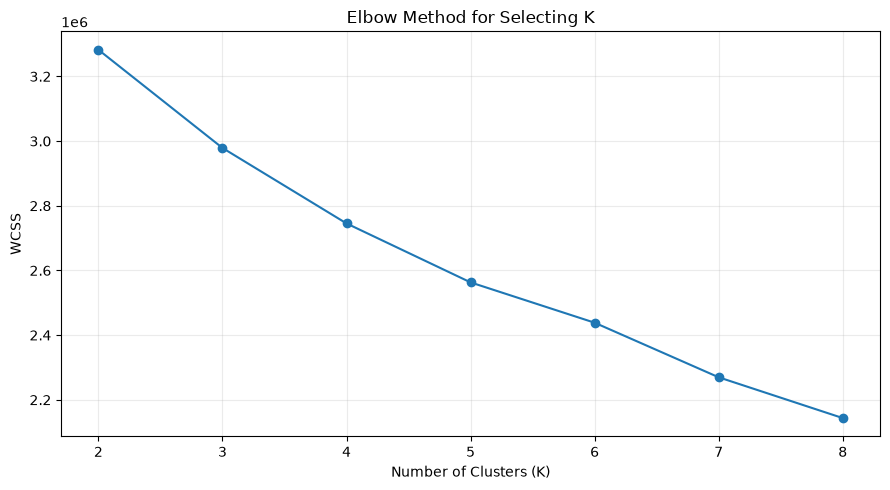

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(
    clustering_results_df["K"],
    clustering_results_df["WCSS"],
    marker="o"
)
ax.set_xlabel("Number of Clusters (K)")
ax.set_ylabel("WCSS")
ax.set_title("Elbow Method for Selecting K")
ax.set_xticks(list(K_VALUES))
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

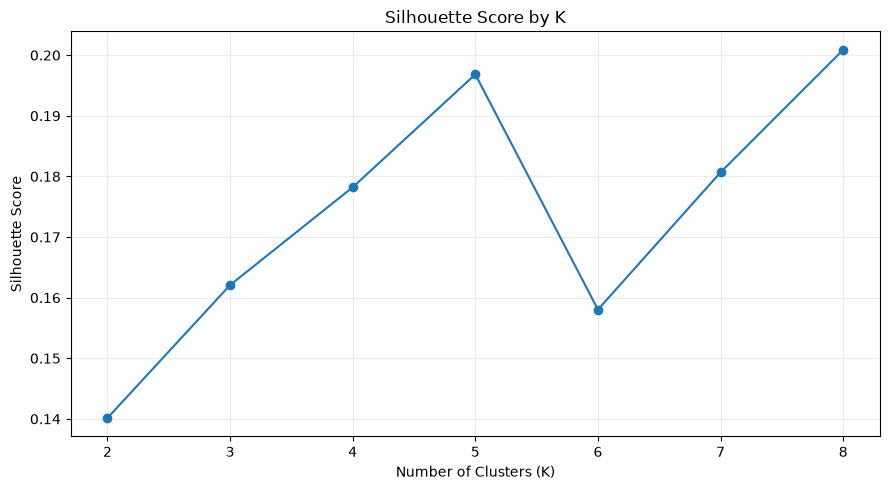

Highest silhouette score occurs at K = 8
Select the final K after considering both the elbow pattern and silhouette results.


In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(
    clustering_results_df["K"],
    clustering_results_df["Silhouette"],
    marker="o"
)
ax.set_xlabel("Number of Clusters (K)")
ax.set_ylabel("Silhouette Score")
ax.set_title("Silhouette Score by K")
ax.set_xticks(list(K_VALUES))
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

best_silhouette_k = int(
    clustering_results_df.loc[
        clustering_results_df["Silhouette"].idxmax(), "K"
    ]
)

print("Highest silhouette score occurs at K =", best_silhouette_k)
print("Select the final K after considering both the elbow pattern and silhouette results.")

## Final K-Means++ Model

The final K should be selected after inspecting the Elbow and Silhouette results. The default below uses the K with the highest silhouette score, but it can be changed manually if the elbow pattern and cluster interpretability support another K.

In [11]:
# Default: K with the highest silhouette score.
# Change FINAL_K manually after inspecting the plots if required.

FINAL_K = int(
    clustering_results_df.loc[
        clustering_results_df["Silhouette"].idxmax(), "K"
    ]
)

print("Selected K:", FINAL_K)

Selected K: 8


In [12]:
final_kmeans = KMeans(
    n_clusters=FINAL_K,
    init="k-means++",
    n_init=20,
    max_iter=300,
    random_state=42,
)

train_cluster_labels = final_kmeans.fit_predict(X_train_cluster)

print("Final clustering completed.")
print("Training cluster distribution:")
print(pd.Series(train_cluster_labels).value_counts().sort_index())
print("\nFinal WCSS:", f"{final_kmeans.inertia_:,.2f}")

Final clustering completed.
Training cluster distribution:
0    15111
1    21824
2    10660
3    62906
4    26589
5    16544
6     2851
7     3793
Name: count, dtype: int64

Final WCSS: 2,143,445.75


## Cluster Profiling

Cluster profiles are summarized using the selected encoded features. Cluster numbers are arbitrary; the actual archetype descriptions should be based on the observed feature profiles.

In [13]:
profile_df = pd.DataFrame(
    X_train_cluster,
    columns=selected_feature_names
)
profile_df["Cluster"] = train_cluster_labels

cluster_sizes = (
    profile_df["Cluster"]
    .value_counts()
    .sort_index()
    .rename("Count")
    .to_frame()
)
cluster_sizes["Percentage"] = (
    cluster_sizes["Count"] / len(profile_df) * 100
)

print("Cluster sizes:")
display(cluster_sizes)

cluster_means = profile_df.groupby("Cluster").mean(numeric_only=True)
display(cluster_means.round(3))

Cluster sizes:


,Count,Percentage
Cluster,,
0,15111,9.427994
1,21824,13.616342
2,10660,6.650944
3,62906,39.248057
4,26589,16.589301
5,16544,10.322065
6,2851,1.778784
7,3793,2.366513


,POLICE_ATTEND_No,POLICE_ATTEND_Not known,POLICE_ATTEND_Yes,DCA_CODE,DCA_CODE_DESCRIPTION_ACCIDENT OR BROKEN DOWN,DCA_CODE_DESCRIPTION_ANY MANOEUVRE INVOLVING PED NOT INCLUDED IN DCAs 100-108.,DCA_CODE_DESCRIPTION_CROSS TRAFFIC(INTERSECTIONS ONLY),DCA_CODE_DESCRIPTION_CUTTING IN (OVERTAKING),DCA_CODE_DESCRIPTION_DOUBLE PARKED,DCA_CODE_DESCRIPTION_ENTERING PARKING,...,SPEED_ZONE_Camping grounds or off road,SPEED_ZONE_Not known,SPEED_ZONE_Other speed limit,OLD_DRIVER_75_AND_OVER,TOTAL_PERSONS,OLD_PED_65_AND_OVER,FEMALES,BICYCLIST,MALES,ROAD_NAME_FREQ
Cluster,,,,,,,,,,,,,,,,,,,,,
0,0.435,0.003,0.562,-0.047,0.000,0.000,0.111,0.004,0.0,0.012,...,0.010,0.098,0.003,-0.106,-0.201,-0.133,-0.318,2.985,-0.015,-0.152
1,0.374,0.003,0.623,0.622,0.000,0.000,0.030,0.002,0.0,0.004,...,0.024,0.112,0.002,-0.199,-0.493,-0.133,-0.598,-0.308,-0.067,-0.138
2,0.255,0.002,0.743,-1.277,0.001,0.075,0.001,0.000,0.0,0.000,...,0.010,0.074,0.009,-0.106,-0.072,-0.133,-0.059,-0.274,-0.144,-0.087
3,0.282,0.005,0.713,-0.439,0.002,0.000,0.119,0.002,0.0,0.001,...,0.001,0.063,0.001,0.110,0.057,-0.133,0.168,-0.322,-0.080,0.055
4,0.120,0.002,0.877,1.381,0.000,0.000,0.000,0.000,0.0,0.000,...,0.005,0.038,0.001,-0.052,-0.626,-0.133,-0.378,-0.321,-0.461,-0.100
5,0.121,0.003,0.877,-0.397,0.002,0.000,0.073,0.002,0.0,0.001,...,0.000,0.030,0.001,0.054,1.729,-0.133,1.108,-0.317,1.295,0.414
6,0.196,0.003,0.801,-1.246,0.002,0.082,0.003,0.000,0.0,0.000,...,0.019,0.089,0.010,0.101,-0.105,7.311,0.010,-0.267,-0.177,-0.090
7,0.165,0.001,0.833,0.473,0.000,0.004,0.134,0.002,0.0,0.002,...,0.008,0.036,0.001,0.089,-0.181,-0.091,-0.106,-0.179,-0.103,-0.299


In [14]:
# Strongest distinguishing encoded features for each cluster.
global_means = profile_df.drop(columns="Cluster").mean()
cluster_z = cluster_means.subtract(global_means, axis=1)

for cluster_id in cluster_z.index:
    strongest = (
        cluster_z.loc[cluster_id]
        .abs()
        .sort_values(ascending=False)
        .head(15)
        .index
    )

    print(f"\nCluster {cluster_id} — strongest distinguishing features")
    display(
        cluster_z.loc[cluster_id, strongest]
        .sort_values(key=np.abs, ascending=False)
        .to_frame("Standardized Difference")
    )


Cluster 0 — strongest distinguishing features


,Standardized Difference
BICYCLIST,2.985037
DRIVER,-0.731451
PASSENGERVEHICLE,-0.675076
MOTORCYCLE,-0.397540
MOTORCYCLIST,-0.396948
YOUNG_DRIVER_18_25,-0.375731
ROAD_ROUTE_1,0.363523
FEMALES,-0.318379
PEDESTRIAN,-0.289852
ACCIDENT_TYPE_Collision with vehicle,0.245932



Cluster 1 — strongest distinguishing features


,Standardized Difference
MOTORCYCLIST,2.437821
MOTORCYCLE,2.437027
DRIVER,-1.174799
PASSENGERVEHICLE,-1.101918
DCA_CODE,0.621599
FEMALES,-0.597930
TOTAL_PERSONS,-0.493041
YOUNG_DRIVER_18_25,-0.420547
NO_OF_VEHICLES,-0.411216
BICYCLIST,-0.308481



Cluster 2 — strongest distinguishing features


...

,Standardized Difference
TOTAL_PERSONS,1.729075
DRIVER,1.726033
NO_OF_VEHICLES,1.722256
PASSENGERVEHICLE,1.628066
MALES,1.294669
FEMALES,1.108283
YOUNG_DRIVER_18_25,0.667772
ROAD_ROUTE_1,-0.561334
ROAD_NAME_FREQ,0.413609
DCA_CODE,-0.397300



Cluster 6 — strongest distinguishing features


,Standardized Difference
OLD_PED_65_AND_OVER,7.310874
PEDESTRIAN,3.060946
DCA_CODE,-1.246081
NO_OF_VEHICLES,-1.032188
ACCIDENT_TYPE_Struck Pedestrian,0.864165
DRIVER,-0.642767
ACCIDENT_TYPE_Collision with vehicle,-0.628833
PASSENGERVEHICLE,-0.608357
DCA_CODE_DESCRIPTION_PED NEAR SIDE. PED HIT BY VEHICLE FROM THE RIGHT.,0.382616
YOUNG_DRIVER_18_25,-0.368728



Cluster 7 — strongest distinguishing features


,Standardized Difference
LATITUDE,3.674119
VICGRID_Y,3.645738
VICGRID_X,-3.039934
LONGITUDE,-2.981117
DEG_URBAN_NAME_MELB_URBAN,-0.625607
DCA_CODE,0.473290
NO_OF_VEHICLES,-0.450018
DEG_URBAN_NAME_RURAL_VICTORIA,0.408852
SPEED_ZONE_100 km/hr,0.341720
PASSENGERVEHICLE,-0.323434


## Relationship Between Crash Archetypes and Severity

Severity is **not** used to create the clusters. It is used only after clustering to describe how the discovered crash groups relate to the target outcome.

In [15]:
severity_names = {
    0: "Fatal",
    1: "Other Injury",
    2: "Serious Injury"
}

severity_profile = pd.crosstab(
    train_cluster_labels,
    pd.Series(y_train).map(severity_names),
    normalize="index"
) * 100

severity_counts = pd.crosstab(
    train_cluster_labels,
    pd.Series(y_train).map(severity_names)
)

print("Severity distribution within each cluster (%)")
display(severity_profile.round(2))

print("Severity counts within each cluster")
display(severity_counts)

Severity distribution within each cluster (%)


col_0,Fatal,Other Injury,Serious Injury
row_0,,,
0,0.74,67.10,32.16
1,2.11,51.14,46.75
2,2.05,56.74,41.21
3,0.83,71.44,27.73
4,2.93,52.53,44.54
5,1.40,63.12,35.49
6,6.38,37.14,56.47
7,4.75,57.82,37.44


Severity counts within each cluster


col_0,Fatal,Other Injury,Serious Injury
row_0,,,
0,112,10140,4859
1,461,11160,10203
2,218,6049,4393
3,519,44943,17444
4,779,13967,11843
5,231,10442,5871
6,182,1059,1610
7,180,2193,1420


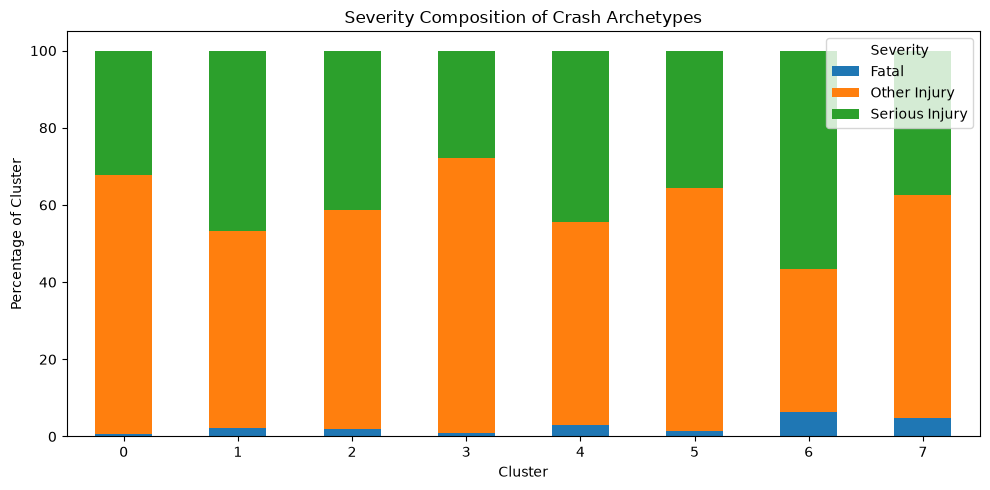

In [16]:
ax = severity_profile.plot(
    kind="bar",
    figsize=(10, 5),
    stacked=True
)
ax.set_xlabel("Cluster")
ax.set_ylabel("Percentage of Cluster")
ax.set_title("Severity Composition of Crash Archetypes")
ax.legend(title="Severity")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Assign Archetypes to the Unseen Test Set

The K-Means model is fitted only on training data. Test crashes are assigned to the nearest learned centroid without refitting the clustering model.

In [17]:
X_test_cluster = X_test_selected.toarray().astype(np.float32)
test_cluster_labels = final_kmeans.predict(X_test_cluster)

print("Test cluster distribution:")
print(pd.Series(test_cluster_labels).value_counts().sort_index())

Test cluster distribution:
0     3737
1     5575
2     2742
3    15546
4     6733
5     4100
6      718
7      919
Name: count, dtype: int64


## Save Cluster Assignments

These labels will be used in the next supervised-learning stage as a new engineered feature.

In [18]:
os.makedirs(DATA_DIR, exist_ok=True)

np.save(
    os.path.join(DATA_DIR, "crash_cluster_train.npy"),
    train_cluster_labels
)

np.save(
    os.path.join(DATA_DIR, "crash_cluster_test.npy"),
    test_cluster_labels
)

np.save(
    os.path.join(DATA_DIR, "crash_cluster_centers.npy"),
    final_kmeans.cluster_centers_
)

clustering_results_df.to_csv(
    os.path.join(DATA_DIR, "kmeans_k_selection_results.csv"),
    index=False
)

cluster_sizes.to_csv(
    os.path.join(DATA_DIR, "crash_cluster_summary.csv")
)

print("Saved:")
print("- crash_cluster_train.npy")
print("- crash_cluster_test.npy")
print("- crash_cluster_centers.npy")
print("- kmeans_k_selection_results.csv")
print("- crash_cluster_summary.csv")

Saved:
- crash_cluster_train.npy
- crash_cluster_test.npy
- crash_cluster_centers.npy
- kmeans_k_selection_results.csv
- crash_cluster_summary.csv


## Key Interpretation Notes

- Cluster numbers are arbitrary labels; Cluster 0 is not inherently lower or higher risk than another cluster.
- Archetypes should be named only after examining their feature profiles and severity composition.
- Severity is used for post-clustering interpretation, not for fitting the clustering model.
- The cluster label can now be tested as an engineered feature in supervised severity prediction.